# Рекуррентные нейронные сети (RNN)

## 1. Импорт библиотек и настройка окружения

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import time
import math

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

Device: cuda
PyTorch version: 2.10.0+cu128


## 2. Визуализация проблем MLP на последовательностях

In [6]:
# Синтетическая задача: определить тренд последовательности
def generate_trend_data(n_samples=2000, seq_len=10):
    X, y = [], []
    for _ in range(n_samples):
        if np.random.rand() > 0.5:
            # Возрастающая
            x = np.sort(np.random.randn(seq_len))
            y.append(1)
        else:
            # Убывающая
            x = np.sort(np.random.randn(seq_len))[::-1].copy()
            y.append(0)
        X.append(x)
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_trend, y_trend = generate_trend_data()
print(f'X: {X_trend.shape}, y: {y_trend.shape}')
print(f'Пример возрастающей: {X_trend[y_trend == 1][0][:5].tolist()}')
print(f'Пример убывающей:   {X_trend[y_trend == 0][0][:5].tolist()}')

X: torch.Size([2000, 10]), y: torch.Size([2000])
Пример возрастающей: [-1.4857122898101807, -1.1350197792053223, -0.6348450183868408, -0.35983526706695557, -0.27392062544822693]
Пример убывающей:   [1.6974695920944214, 0.9857183694839478, 0.17979024350643158, 0.05108953267335892, -0.0265143234282732]


In [7]:
# MLP — перемешаем порядок элементов внутри каждой последовательности
mlp = nn.Sequential(
    nn.Linear(10, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)

# Обучим на исходных данных
opt_mlp = optim.Adam(mlp.parameters(), lr=1e-3)
for epoch in range(50):
    logits = mlp(X_trend)
    loss = F.cross_entropy(logits, y_trend)
    opt_mlp.zero_grad()
    loss.backward()
    opt_mlp.step()

with torch.no_grad():
    acc_ordered = (mlp(X_trend).argmax(1) == y_trend).float().mean()
    # Перемешаем элементы в каждой последовательности
    X_shuffled = X_trend.clone()
    for i in range(len(X_shuffled)):
        idx = torch.randperm(X_shuffled.size(1))
        X_shuffled[i] = X_shuffled[i][idx]
    acc_shuffled = (mlp(X_shuffled).argmax(1) == y_trend).float().mean()

print(f'MLP accuracy (ordered):  {acc_ordered:.3f}')
print(f'MLP accuracy (shuffled): {acc_shuffled:.3f}')
print('  MLP теряет точность при перемешивании, но не полностью — он использует')
print('  статистику значений (макс, мин), а не порядок')

MLP accuracy (ordered):  1.000
MLP accuracy (shuffled): 0.501
  MLP теряет точность при перемешивании, но не полностью — он использует
  статистику значений (макс, мин), а не порядок


In [8]:
# Простая RNN для той же задачи
class SimpleRNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True)
        self.fc  = nn.Linear(16, 2)

    def forward(self, x):
        # x: (B, 10) -> (B, 10, 1)
        out, h_n = self.rnn(x.unsqueeze(-1))
        return self.fc(h_n.squeeze(0))

rnn_model = SimpleRNNClassifier()
opt_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)

for epoch in range(50):
    logits = rnn_model(X_trend)
    loss = F.cross_entropy(logits, y_trend)
    opt_rnn.zero_grad()
    loss.backward()
    opt_rnn.step()

with torch.no_grad():
    acc_rnn_ordered  = (rnn_model(X_trend).argmax(1) == y_trend).float().mean()
    acc_rnn_shuffled = (rnn_model(X_shuffled).argmax(1) == y_trend).float().mean()

print(f'RNN accuracy (ordered):  {acc_rnn_ordered:.3f}')
print(f'RNN accuracy (shuffled): {acc_rnn_shuffled:.3f}')
print('  RNN лучше справляется с упорядоченными данными,')
print('  но проваливается на перемешанных — она ЗАВИСИТ от порядка')

RNN accuracy (ordered):  0.996
RNN accuracy (shuffled): 0.496
  RNN лучше справляется с упорядоченными данными,
  но проваливается на перемешанных — она ЗАВИСИТ от порядка


## 3. Реализация RNN-ячейки с нуля

RNN разворачивается по времени и обучается через **BPTT** (Backpropagation Through Time): градиент проходит через все шаги назад.

**Две типичные проблемы:**
- **Затухающий градиент** — решается через LSTM/GRU с gate-механизмом.
- **Взрывной градиент** — `clip_grad_norm_(params, max_norm=1.0)` масштабирует градиент, сохраняя направление.

In [9]:
class RNNCellFromScratch(nn.Module):
    """Ручная реализация одной RNN-ячейки."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Параметры
        self.W_x = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.W_h = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b   = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x_t, h_prev):
        """
        x_t:    (batch, input_size)
        h_prev: (batch, hidden_size)
        Returns: h_t (batch, hidden_size)
        """
        z = x_t @ self.W_x.T + h_prev @ self.W_h.T + self.b
        h_t = torch.tanh(z)
        return h_t


class RNNFromScratch(nn.Module):
    """Полная RNN: развёртка ячейки по T шагам."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = RNNCellFromScratch(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, h0=None):
        """
        x:  (batch, seq_len, input_size)
        h0: (batch, hidden_size) or None
        Returns: outputs (batch, seq_len, hidden_size), h_n (batch, hidden_size)
        """
        B, T, _ = x.shape
        if h0 is None:
            h0 = torch.zeros(B, self.hidden_size, device=x.device)

        h = h0
        outputs = []
        for t in range(T):
            h = self.cell(x[:, t, :], h)
            outputs.append(h)

        return torch.stack(outputs, dim=1), h


# Тест: сравним с nn.RNN
torch.manual_seed(42)
my_rnn = RNNFromScratch(input_size=10, hidden_size=20)
x_test = torch.randn(4, 5, 10)
out, h_last = my_rnn(x_test)
print(f'Output shape: {out.shape}')       # (4, 5, 20)
print(f'Last hidden:  {h_last.shape}')    # (4, 20)
print(f'Совпадает:    {torch.allclose(out[:, -1, :], h_last)}')

Output shape: torch.Size([4, 5, 20])
Last hidden:  torch.Size([4, 20])
Совпадает:    True


## 4. One-Hot кодирование и эмбеддинги

In [10]:
# One-Hot кодирование
vocab_size = 26  # a-z
chars = 'hello'
indices = torch.tensor([ord(c) - ord('a') for c in chars])

one_hot = F.one_hot(indices, num_classes=vocab_size).float()
print(f'One-Hot shape: {one_hot.shape}')  # (5, 26)
print(f'Плотность (% ненулевых): {(one_hot != 0).float().mean() * 100:.1f}%')

# Расстояние между любыми двумя символами
d_he = torch.dist(one_hot[0], one_hot[1])  # h vs e
d_hl = torch.dist(one_hot[0], one_hot[2])  # h vs l
print(f'Dist(h, e) = {d_he:.4f}')
print(f'Dist(h, l) = {d_hl:.4f}')
print('  Все расстояния = sqrt(2), семантика не учитывается')

One-Hot shape: torch.Size([5, 26])
Плотность (% ненулевых): 3.8%
Dist(h, e) = 1.4142
Dist(h, l) = 1.4142
  Все расстояния = sqrt(2), семантика не учитывается


In [11]:
# Embedding: обучаемые плотные векторы
embed_dim = 8
embedding = nn.Embedding(vocab_size, embed_dim)

# Прогоним те же символы
embedded = embedding(indices)
print(f'Embedding shape: {embedded.shape}')  # (5, 8)
print(f'Плотность: {(embedded != 0).float().mean() * 100:.1f}%')
print(f'Параметры: {vocab_size * embed_dim} = {vocab_size} × {embed_dim}')

# Расстояния до обучения — случайные
with torch.no_grad():
    d_he = torch.dist(embedded[0], embedded[1])
    d_hl = torch.dist(embedded[0], embedded[2])
print(f'\nDist(h, e) = {d_he:.4f}')
print(f'Dist(h, l) = {d_hl:.4f}')
print('  Расстояния различаются. После обучения станут семантически осмысленными')

Embedding shape: torch.Size([5, 8])
Плотность: 100.0%
Параметры: 208 = 26 × 8

Dist(h, e) = 4.1533
Dist(h, l) = 4.3060
  Расстояния различаются. После обучения станут семантически осмысленными


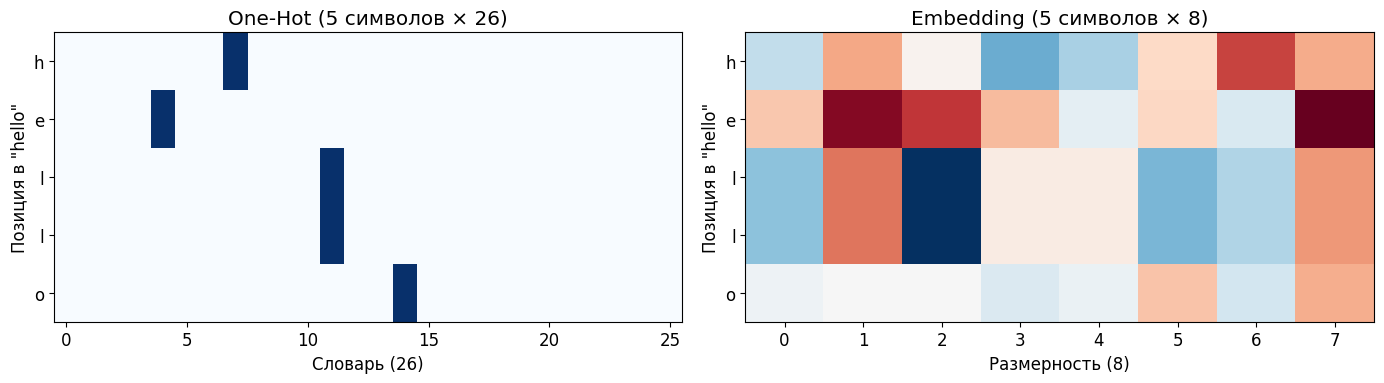

In [12]:
# Визуализация: One-Hot (разреженный) vs Embedding (плотный)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(one_hot.numpy(), cmap='Blues', aspect='auto')
axes[0].set_title('One-Hot (5 символов × 26)')
axes[0].set_xlabel('Словарь (26)')
axes[0].set_ylabel('Позиция в "hello"')
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(list('hello'))

axes[1].imshow(embedded.detach().numpy(), cmap='RdBu', aspect='auto')
axes[1].set_title(f'Embedding (5 символов × {embed_dim})')
axes[1].set_xlabel(f'Размерность ({embed_dim})')
axes[1].set_ylabel('Позиция в "hello"')
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(list('hello'))

plt.tight_layout()
plt.savefig('onehot_vs_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. nn.RNN, nn.LSTM, nn.GRU — интерфейс и размерности

In [13]:
print('=' * 60)
print('nn.RNN')
print('=' * 60)
rnn = nn.RNN(input_size=50, hidden_size=128, num_layers=2, batch_first=True)

x = torch.randn(8, 20, 50)       # (B=8, T=20, d_x=50)
h0 = torch.zeros(2, 8, 128)      # (num_layers, B, d_h)

y, h_n = rnn(x, h0)
print(f'  y:    {y.shape}')        # (8, 20, 128) — все шаги
print(f'  h_n:  {h_n.shape}')      # (2, 8, 128)  — последний шаг, все слои

# Параметры
n_params = sum(p.numel() for p in rnn.parameters())
print(f'  Params: {n_params:,}')
for name, p in rnn.named_parameters():
    print(f'    {name:25s} {list(p.shape)}')

nn.RNN
  y:    torch.Size([8, 20, 128])
  h_n:  torch.Size([2, 8, 128])
  Params: 56,064
    weight_ih_l0              [128, 50]
    weight_hh_l0              [128, 128]
    bias_ih_l0                [128]
    bias_hh_l0                [128]
    weight_ih_l1              [128, 128]
    weight_hh_l1              [128, 128]
    bias_ih_l1                [128]
    bias_hh_l1                [128]


In [14]:
print('=' * 60)
print('nn.LSTM')
print('=' * 60)
lstm = nn.LSTM(input_size=50, hidden_size=128, num_layers=2, batch_first=True)

x = torch.randn(8, 20, 50)
h0 = torch.zeros(2, 8, 128)
c0 = torch.zeros(2, 8, 128)      # ← cell state

y, (h_n, c_n) = lstm(x, (h0, c0))
print(f'  y:    {y.shape}')        # (8, 20, 128)
print(f'  h_n:  {h_n.shape}')      # (2, 8, 128)
print(f'  c_n:  {c_n.shape}')      # (2, 8, 128) ← отличие от RNN!

n_params = sum(p.numel() for p in lstm.parameters())
print(f'  Params: {n_params:,}')
for name, p in lstm.named_parameters():
    print(f'    {name:25s} {list(p.shape)}')

print('\n   weight_ih: [512, 50] = 4 × 128 × 50')
print('   weight_hh: [512, 128] = 4 × 128 × 128')

nn.LSTM
  y:    torch.Size([8, 20, 128])
  h_n:  torch.Size([2, 8, 128])
  c_n:  torch.Size([2, 8, 128])
  Params: 224,256
    weight_ih_l0              [512, 50]
    weight_hh_l0              [512, 128]
    bias_ih_l0                [512]
    bias_hh_l0                [512]
    weight_ih_l1              [512, 128]
    weight_hh_l1              [512, 128]
    bias_ih_l1                [512]
    bias_hh_l1                [512]

   weight_ih: [512, 50] = 4 × 128 × 50
   weight_hh: [512, 128] = 4 × 128 × 128


In [15]:
print('=' * 60)
print('nn.GRU')
print('=' * 60)
gru = nn.GRU(input_size=50, hidden_size=128, num_layers=2, batch_first=True)

x = torch.randn(8, 20, 50)
h0 = torch.zeros(2, 8, 128)

y, h_n = gru(x, h0)             # нет c_n!
print(f'  y:    {y.shape}')
print(f'  h_n:  {h_n.shape}')

n_params = sum(p.numel() for p in gru.parameters())
print(f'  Params: {n_params:,}')
for name, p in gru.named_parameters():
    print(f'    {name:25s} {list(p.shape)}')

print('\n   weight_ih: [384, 50] = 3 × 128 × 50')

nn.GRU
  y:    torch.Size([8, 20, 128])
  h_n:  torch.Size([2, 8, 128])
  Params: 168,192
    weight_ih_l0              [384, 50]
    weight_hh_l0              [384, 128]
    bias_ih_l0                [384]
    bias_hh_l0                [384]
    weight_ih_l1              [384, 128]
    weight_hh_l1              [384, 128]
    bias_ih_l1                [384]
    bias_hh_l1                [384]

   weight_ih: [384, 50] = 3 × 128 × 50


In [21]:
# # Сводная таблица параметров
# d_x, d_h = 50, 128
# print(f'Размерности: d_x={d_x}, d_h={d_h}')
# print(f'{'Архитектура':12s} | {'Формула':35s} | {'Параметры':>12s}')
# print('-' * 65)

# p_rnn  = d_h * (d_x + d_h + 1)
# p_lstm = 4 * d_h * (d_x + d_h + 1)
# p_gru  = 3 * d_h * (d_x + d_h + 1)

# print(f'{'RNN':12s} | {'d_h(d_x + d_h + 1)':35s} | {p_rnn:>12,}')
# print(f'{'LSTM':12s} | {'4*d_h(d_x + d_h + 1)':35s} | {p_lstm:>12,}')
# print(f'{'GRU':12s} | {'3*d_h(d_x + d_h + 1)':35s} | {p_gru:>12,}')
# print(f'\nОтношение LSTM/RNN: {p_lstm/p_rnn:.1f}x')
# print(f'Отношение GRU/RNN:  {p_gru/p_rnn:.1f}x')

## 6. Двунаправленная RNN

In [22]:
bi_lstm = nn.LSTM(input_size=50, hidden_size=128,
                  num_layers=2, batch_first=True, bidirectional=True)

x = torch.randn(8, 20, 50)
y, (h_n, c_n) = bi_lstm(x)

print(f'y:   {y.shape}')     # (8, 20, 256) - 2 × 128
print(f'h_n: {h_n.shape}')   # (4, 8, 128)  - 2 layers × 2 directions
print(f'c_n: {c_n.shape}')   # (4, 8, 128)

# Для Many-to-One: конкатенация прямого и обратного
# h_n[-2] — forward последнего слоя
# h_n[-1] — backward последнего слоя
h_fwd = h_n[-2]  # (8, 128)
h_bwd = h_n[-1]  # (8, 128)
context = torch.cat([h_fwd, h_bwd], dim=-1)  # (8, 256)
print(f'\nContext vector: {context.shape}')

n_params = sum(p.numel() for p in bi_lstm.parameters())
print(f'Params: {n_params:,} (≈ 2× unidirectional LSTM)')

y:   torch.Size([8, 20, 256])
h_n: torch.Size([4, 8, 128])
c_n: torch.Size([4, 8, 128])

Context vector: torch.Size([8, 256])
Params: 579,584 (≈ 2× unidirectional LSTM)


## 7. LSTM-ячейка с нуля

Реализуем LSTM полностью вручную, чтобы увидеть каждый gate.

In [23]:
class LSTMCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        # Объединённая матрица для всех 4 gates: [f, i, c~, o]
        self.W = nn.Parameter(torch.randn(4 * hidden_size, input_size + hidden_size) * 0.01)
        self.b = nn.Parameter(torch.zeros(4 * hidden_size))
        # Инициализация bias forget gate = 1.0
        nn.init.constant_(self.b[:hidden_size], 1.0)

    def forward(self, x_t, h_prev, c_prev):
        """
        x_t:    (B, input_size)
        h_prev: (B, hidden_size)
        c_prev: (B, hidden_size)
        """
        combined = torch.cat([h_prev, x_t], dim=-1)   # (B, hidden+input)
        gates = combined @ self.W.T + self.b          # (B, 4*hidden)

        H = self.hidden_size
        f_t = torch.sigmoid(gates[:, 0*H : 1*H])     # forget gate
        i_t = torch.sigmoid(gates[:, 1*H : 2*H])     # input gate
        c_tilde = torch.tanh(gates[:, 2*H : 3*H])    # candidate
        o_t = torch.sigmoid(gates[:, 3*H : 4*H])     # output gate

        c_t = f_t * c_prev + i_t * c_tilde           # cell state update
        h_t = o_t * torch.tanh(c_t)                  # hidden state

        return h_t, c_t, {'f': f_t, 'i': i_t, 'o': o_t, 'c_tilde': c_tilde}


class LSTMFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = LSTMCellFromScratch(input_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, h0=None, c0=None):
        B, T, _ = x.shape
        H = self.hidden_size
        if h0 is None:
            h0 = torch.zeros(B, H, device=x.device)
        if c0 is None:
            c0 = torch.zeros(B, H, device=x.device)

        h, c = h0, c0
        outputs, gate_history = [], []
        for t in range(T):
            h, c, gates = self.cell(x[:, t, :], h, c)
            outputs.append(h)
            gate_history.append(gates)

        return torch.stack(outputs, dim=1), h, c, gate_history


# Тест
my_lstm = LSTMFromScratch(input_size=10, hidden_size=20)
x_test = torch.randn(4, 15, 10)
out, h, c, gates = my_lstm(x_test)
print(f'Output: {out.shape}')    # (4, 15, 20)
print(f'h:      {h.shape}')      # (4, 20)
print(f'c:      {c.shape}')      # (4, 20)
print(f'Gates:  {len(gates)} steps, keys: {list(gates[0].keys())}')

Output: torch.Size([4, 15, 20])
h:      torch.Size([4, 20])
c:      torch.Size([4, 20])
Gates:  15 steps, keys: ['f', 'i', 'o', 'c_tilde']


## 8. Языковое моделирование на уровне символов (CharRNN)

Обучим LSTM предсказывать следующий символ и генерировать текст.

In [25]:
# Датасет: скачиваем текст
import urllib.request

url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
urllib.request.urlretrieve(url, 'shakespeare.txt')

with open('shakespeare.txt', 'r') as f:
    text = f.read()

print(f'Длина текста: {len(text):,} символов')
print(f'Пример:\n{text[:200]}')

Длина текста: 1,115,394 символов
Пример:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [26]:
# Словарь символов
chars = sorted(set(text))
vocab_size = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}

print(f'Размер словаря: {vocab_size}')
print(f'Символы: {repr("".join(chars[:30]))} ...')

# Кодирование текста
data = torch.tensor([char2idx[c] for c in text], dtype=torch.long)
print(f'data shape: {data.shape}')

Размер словаря: 65
Символы: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQ" ...
data shape: torch.Size([1115394])


In [27]:
# Модель CharRNN
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.dropout(self.embedding(x))
        out, hidden = self.lstm(emb, hidden)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (h, c)


model = CharRNN(vocab_size, embed_dim=64, hidden_size=256,
                num_layers=2, dropout=0.3).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Модель создана: {n_params:,} параметров')
print(model)

Модель создана: 876,929 параметров
CharRNN(
  (embedding): Embedding(65, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)


In [28]:
# Подготовка батчей для обучения
SEQ_LEN = 100
BATCH   = 64

n_batches = (len(data) - 1) // (BATCH * SEQ_LEN)
data_trim = data[: n_batches * BATCH * SEQ_LEN + 1]
x_data = data_trim[:-1].view(BATCH, -1)   # (BATCH, total_steps)
y_data = data_trim[1:].view(BATCH, -1)

print(f'Батчей за эпоху: {x_data.size(1) // SEQ_LEN}')
print(f'x_data: {x_data.shape}')
print(f'y_data: {y_data.shape}')

Батчей за эпоху: 174
x_data: torch.Size([64, 17400])
y_data: torch.Size([64, 17400])


In [29]:
# Обучение
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

NUM_EPOCHS = 10
losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    hidden = model.init_hidden(BATCH, device)
    epoch_loss = 0.0
    n_steps = 0

    for i in range(0, x_data.size(1), SEQ_LEN):
        x_batch = x_data[:, i:i+SEQ_LEN].to(device)
        y_batch = y_data[:, i:i+SEQ_LEN].to(device)

        if x_batch.size(1) < SEQ_LEN:
            break

        hidden = tuple(h.detach() for h in hidden)

        logits, hidden = model(x_batch, hidden)
        loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_steps += 1

    scheduler.step()
    avg_loss = epoch_loss / n_steps
    ppl = math.exp(avg_loss)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | PPL: {ppl:.2f} | LR: {scheduler.get_last_lr()[0]:.6f}')

Epoch  1/10 | Loss: 2.5418 | PPL: 12.70 | LR: 0.001951
Epoch  2/10 | Loss: 1.9547 | PPL: 7.06 | LR: 0.001809
Epoch  3/10 | Loss: 1.7835 | PPL: 5.95 | LR: 0.001588
Epoch  4/10 | Loss: 1.6949 | PPL: 5.45 | LR: 0.001309
Epoch  5/10 | Loss: 1.6396 | PPL: 5.15 | LR: 0.001000
Epoch  6/10 | Loss: 1.6041 | PPL: 4.97 | LR: 0.000691
Epoch  7/10 | Loss: 1.5803 | PPL: 4.86 | LR: 0.000412
Epoch  8/10 | Loss: 1.5635 | PPL: 4.78 | LR: 0.000191
Epoch  9/10 | Loss: 1.5542 | PPL: 4.73 | LR: 0.000049
Epoch 10/10 | Loss: 1.5493 | PPL: 4.71 | LR: 0.000000


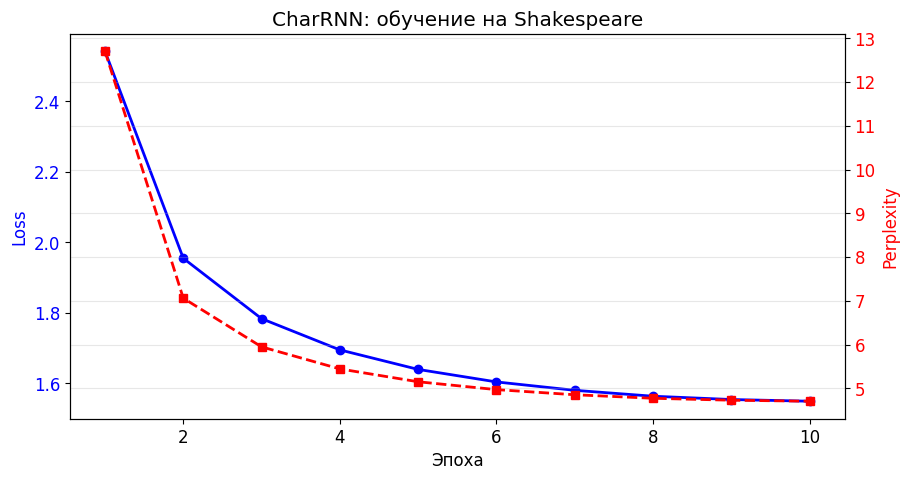

In [30]:
# График обучения
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(range(1, len(losses)+1), losses, 'b-o', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ppls = [math.exp(l) for l in losses]
ax2.plot(range(1, len(losses)+1), ppls, 'r--s', linewidth=2)
ax2.set_ylabel('Perplexity', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('CharRNN: обучение на Shakespeare')
plt.grid(True, alpha=0.3)
plt.savefig('charRNN_training.png', dpi=150, bbox_inches='tight')
plt.show()

### Генерация: параметр `temperature`

После обучения модель выдаёт логиты, из которых сэмплируется следующий символ. `temperature` делит логиты перед softmax:

```python
probs = softmax(logits / temperature)
```

| temperature | Эффект |
|-------------|--------|
| → 0 | Жадный выбор, текст детерминированный и повторяющийся |
| = 1 | Стандартное распределение модели |
| > 1 | Распределение сглаживается, текст разнообразнее, но менее связный |

In [31]:
# Генерация текста
def generate(model, seed_text, length=500, temperature=0.8):
    model.eval()
    chars_enc = [char2idx.get(c, 0) for c in seed_text]
    x = torch.tensor(chars_enc, dtype=torch.long).unsqueeze(0).to(device)
    hidden = model.init_hidden(1, device)

    with torch.no_grad():
        _, hidden = model(x, hidden)
        last = torch.tensor([[chars_enc[-1]]], dtype=torch.long, device=device)
        result = seed_text

        for _ in range(length):
            logits, hidden = model(last, hidden)
            probs = F.softmax(logits[0, 0] / temperature, dim=-1)
            idx = torch.multinomial(probs, 1).item()
            result += idx2char[idx]
            last = torch.tensor([[idx]], dtype=torch.long, device=device)

    return result

# Генерация при разных температурах
for temp in [0.3, 0.7, 1.0, 1.5]:
    print(f'\n{"="*60}')
    print(f'Temperature = {temp}')
    print('='*60)
    print(generate(model, 'The king ', length=200, temperature=temp))


Temperature = 0.3
The king of the strange
That we may so be so the courtesters,
To the shall see the fair the person of the death,
And the see the blood of the strange of the world,
And see the father with the grace of the coun

Temperature = 0.7
The king our son,
Shall be a gatens to hear it not do.

Flown:
Ay, and say the ready repast never I lady
Madan prived, this father have be he so gerther,
I have not sun steed friends and parting have renight.


Temperature = 1.0
The king Parua,
And thee you'll do make may say your groces
The fore the pricposumy, what shall deas field to his;
Which bit no reisure poor better and him.

KING RICHARD III:
How thou know you his of Wy nets 

Temperature = 1.5
The king wry secO.
By you! had: which do eose him me honour womat!
How the provideme end: stay't for botw!

KIUG RICHARD IWI:
Narifurout: how way hims Masteder SwiMe;
If it at talliat in paecous, but Jrumes
A 


## 9. Сентимент-анализ на IMDb (BiLSTM)

Задача: по тексту отзыва предсказать тональность (positive / negative).

**`padding_idx` в `nn.Embedding`:** все последовательности в батче выравниваются до одной длины PAD-токенами (индекс 0). Параметр `padding_idx=0` гарантирует, что эмбеддинг PAD-токена всегда остаётся нулевым и не участвует в обучении — это предотвращает «загрязнение» градиентов от фиктивных позиций.

In [32]:
# Загрузка IMDb
try:
    from datasets import load_dataset
    imdb = load_dataset('imdb')
    print(f'Train: {len(imdb["train"])}, Test: {len(imdb["test"])}')
except ImportError:
    print('pip install datasets')
    raise

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 25000, Test: 25000


In [33]:
# Токенизация и словарь
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# Строим словарь на train
all_words = []
for sample in imdb['train']:
    all_words.extend(tokenize(sample['text']))

counter = Counter(all_words)
MAX_VOCAB = 20_000
vocab = ['<pad>', '<unk>'] + [w for w, _ in counter.most_common(MAX_VOCAB)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
PAD_IDX, UNK_IDX = 0, 1

print(f'Словарь: {VOCAB_SIZE} слов')
print(f'Топ-10: {[w for w, _ in counter.most_common(10)]}')

MAX_LEN = 256
def encode(text):
    tokens = tokenize(text)[:MAX_LEN]
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return ids

Словарь: 20002 слов
Топ-10: ['the', 'and', 'a', 'of', 'to', 'is', 'br', 'it', 'in', 'i']


In [34]:
# Dataset и DataLoader
class SentimentDataset(Dataset):
    def __init__(self, data):
        self.texts  = [torch.tensor(encode(s['text']), dtype=torch.long) for s in data]
        self.labels = [torch.tensor(s['label'], dtype=torch.long) for s in data]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_ds = SentimentDataset(imdb['train'])
test_ds  = SentimentDataset(imdb['test'])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Проверка
x_sample, y_sample = next(iter(train_loader))
print(f'x: {x_sample.shape}, y: {y_sample.shape}')

x: torch.Size([64, 256]), y: torch.Size([64])


In [35]:
# BiLSTM классификатор
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size,
                 num_layers, num_classes, dropout=0.4, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden_size, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (h_n, _) = self.lstm(emb)
        h_fwd = h_n[-2]
        h_bwd = h_n[-1]
        h_cat = self.dropout(torch.cat([h_fwd, h_bwd], dim=-1))
        return self.fc(h_cat)


sent_model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_size=256,
    num_layers=2, num_classes=2, dropout=0.4
).to(device)

n_params = sum(p.numel() for p in sent_model.parameters() if p.requires_grad)
print(f'Параметров: {n_params:,}')
print(sent_model)

Параметров: 4,928,770
BiLSTMClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)


In [36]:
# Функции обучения и оценки
def get_optimizer(model, lr=1e-3, weight_decay=1e-2):
    decay = [p for n, p in model.named_parameters()
             if p.requires_grad and 'bias' not in n and 'embedding' not in n]
    no_decay = [p for n, p in model.named_parameters()
                if p.requires_grad and ('bias' in n or 'embedding' in n)]
    return optim.AdamW([
        {'params': decay,    'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0}
    ], lr=lr)


def epoch_pass(model, loader, optimizer=None, criterion=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * y_batch.size(0)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

In [37]:
# Обучение BiLSTM на IMDb
criterion = nn.CrossEntropyLoss()
optimizer = get_optimizer(sent_model, lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor=0.5, patience=1)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(5):
    t0 = time.time()
    tr_loss, tr_acc = epoch_pass(sent_model, train_loader, optimizer, criterion, train=True)
    va_loss, va_acc = epoch_pass(sent_model, test_loader,  optimizer, criterion, train=False)
    scheduler.step(va_acc)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch+1}/5 [{elapsed:.0f}s] | '
          f'Train: loss={tr_loss:.4f} acc={tr_acc:.3f} | '
          f'Val: loss={va_loss:.4f} acc={va_acc:.3f}')

Epoch 1/5 [10s] | Train: loss=0.6941 acc=0.528 | Val: loss=0.6899 acc=0.520
Epoch 2/5 [10s] | Train: loss=0.6416 acc=0.628 | Val: loss=0.5795 acc=0.703
Epoch 3/5 [10s] | Train: loss=0.5198 acc=0.751 | Val: loss=0.4417 acc=0.810
Epoch 4/5 [10s] | Train: loss=0.4196 acc=0.812 | Val: loss=0.3914 acc=0.829
Epoch 5/5 [10s] | Train: loss=0.3538 acc=0.849 | Val: loss=0.3502 acc=0.853


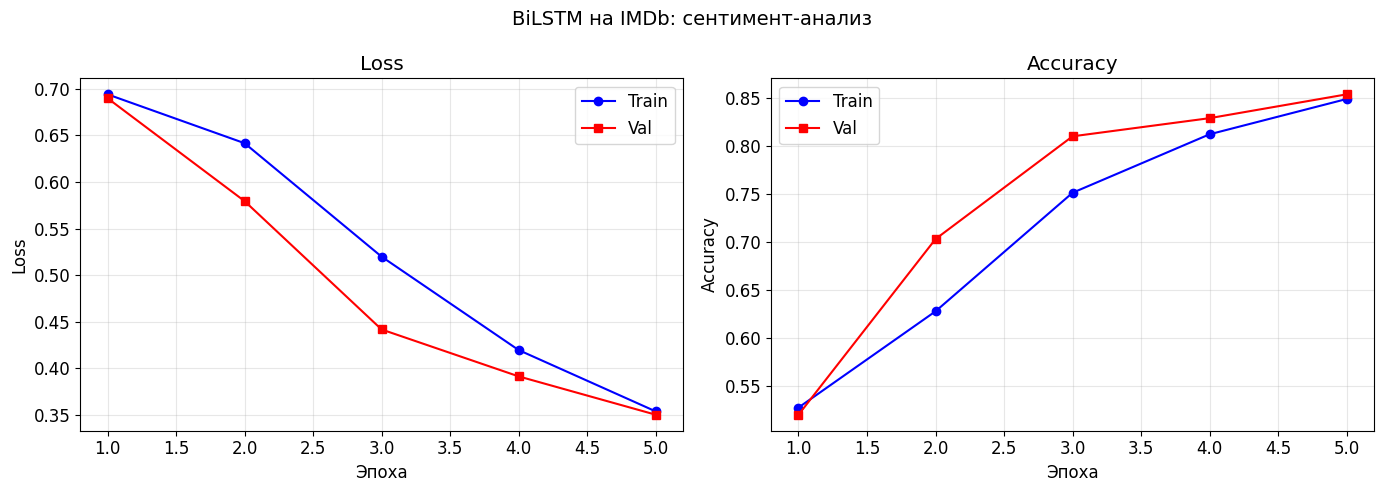

In [39]:
# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs, history['val_loss'],   'r-s', label='Val')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax2.plot(epochs, history['val_acc'],   'r-s', label='Val')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy')
ax2.grid(True, alpha=0.3)

plt.suptitle('BiLSTM на IMDb: сентимент-анализ', fontsize=14)
plt.tight_layout()
plt.savefig('bilstm_imdb.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Сравнительный эксперимент: RNN vs LSTM vs GRU

In [40]:
class TextClassifier(nn.Module):
    def __init__(self, rnn_type, vocab_size, embed_dim,
                 hidden_size, num_layers, num_classes,
                 dropout=0.3, pad_idx=0):
        super().__init__()
        self.rnn_type = rnn_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)

        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size=embed_dim, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        if self.rnn_type == 'LSTM':
            out, (h_n, _) = self.rnn(emb)
        else:
            out, h_n = self.rnn(emb)
        return self.fc(self.dropout(h_n[-1]))


CONFIG = dict(vocab_size=VOCAB_SIZE, embed_dim=128,
              hidden_size=128, num_layers=2,
              num_classes=2, dropout=0.3)

results = {}
for arch in ['RNN', 'LSTM', 'GRU']:
    print(f'\n{"="*40} {arch} {"="*40}')
    m = TextClassifier(rnn_type=arch, **CONFIG).to(device)
    opt = get_optimizer(m, lr=1e-3)
    crit = nn.CrossEntropyLoss()
    n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)

    for ep in range(3):
        tr_l, tr_a = epoch_pass(m, train_loader, opt, crit, train=True)
        va_l, va_a = epoch_pass(m, test_loader,  opt, crit, train=False)
        print(f'  Epoch {ep+1} | Train acc: {tr_a:.3f} | Val acc: {va_a:.3f}')

    results[arch] = {'val_acc': va_a, 'params': n_p}
    print(f'  {arch}: Val acc = {va_a:.3f}, Params = {n_p:,}')


======================================== RNN ========================================
  Epoch 1 | Train acc: 0.502 | Val acc: 0.503
  Epoch 2 | Train acc: 0.510 | Val acc: 0.506
  Epoch 3 | Train acc: 0.514 | Val acc: 0.495
  RNN: Val acc = 0.495, Params = 2,626,562

======================================== LSTM ========================================
  Epoch 1 | Train acc: 0.510 | Val acc: 0.520
  Epoch 2 | Train acc: 0.520 | Val acc: 0.515
  Epoch 3 | Train acc: 0.537 | Val acc: 0.506
  LSTM: Val acc = 0.506, Params = 2,824,706

======================================== GRU ========================================
  Epoch 1 | Train acc: 0.514 | Val acc: 0.518
  Epoch 2 | Train acc: 0.526 | Val acc: 0.552
  Epoch 3 | Train acc: 0.558 | Val acc: 0.525
  GRU: Val acc = 0.525, Params = 2,758,658


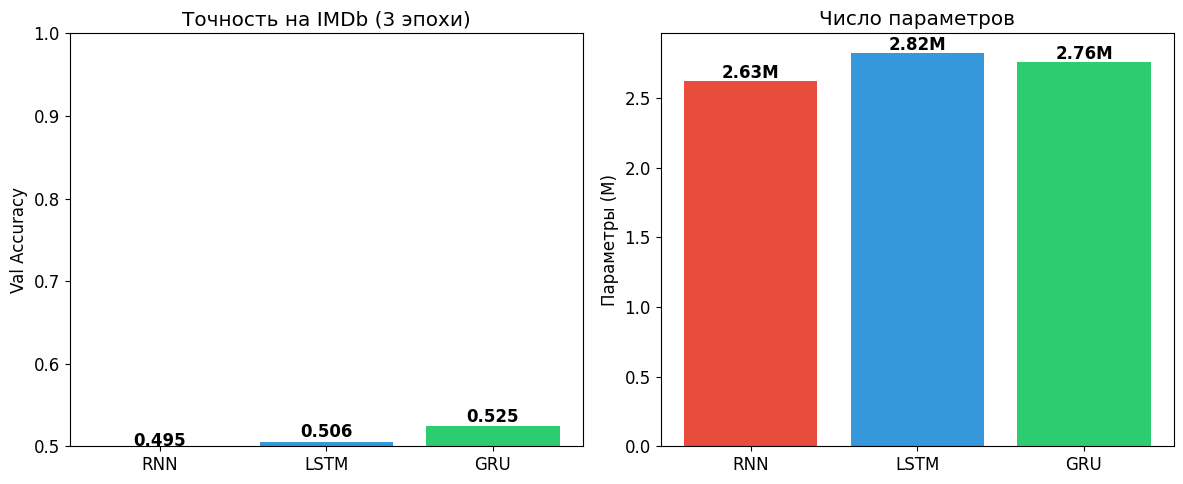

In [41]:
# Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

archs = list(results.keys())
accs  = [results[a]['val_acc'] for a in archs]
params = [results[a]['params'] for a in archs]
colors = ['#e74c3c', '#3498db', '#2ecc71']

ax1.bar(archs, accs, color=colors)
ax1.set_ylabel('Val Accuracy')
ax1.set_title('Точность на IMDb (3 эпохи)')
ax1.set_ylim(0.5, 1.0)
for i, v in enumerate(accs):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

ax2.bar(archs, [p / 1e6 for p in params], color=colors)
ax2.set_ylabel('Параметры (M)')
ax2.set_title('Число параметров')
for i, v in enumerate(params):
    ax2.text(i, v/1e6 + 0.02, f'{v/1e6:.2f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('rnn_lstm_gru_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Визуализация: gate-активации LSTM и hidden states

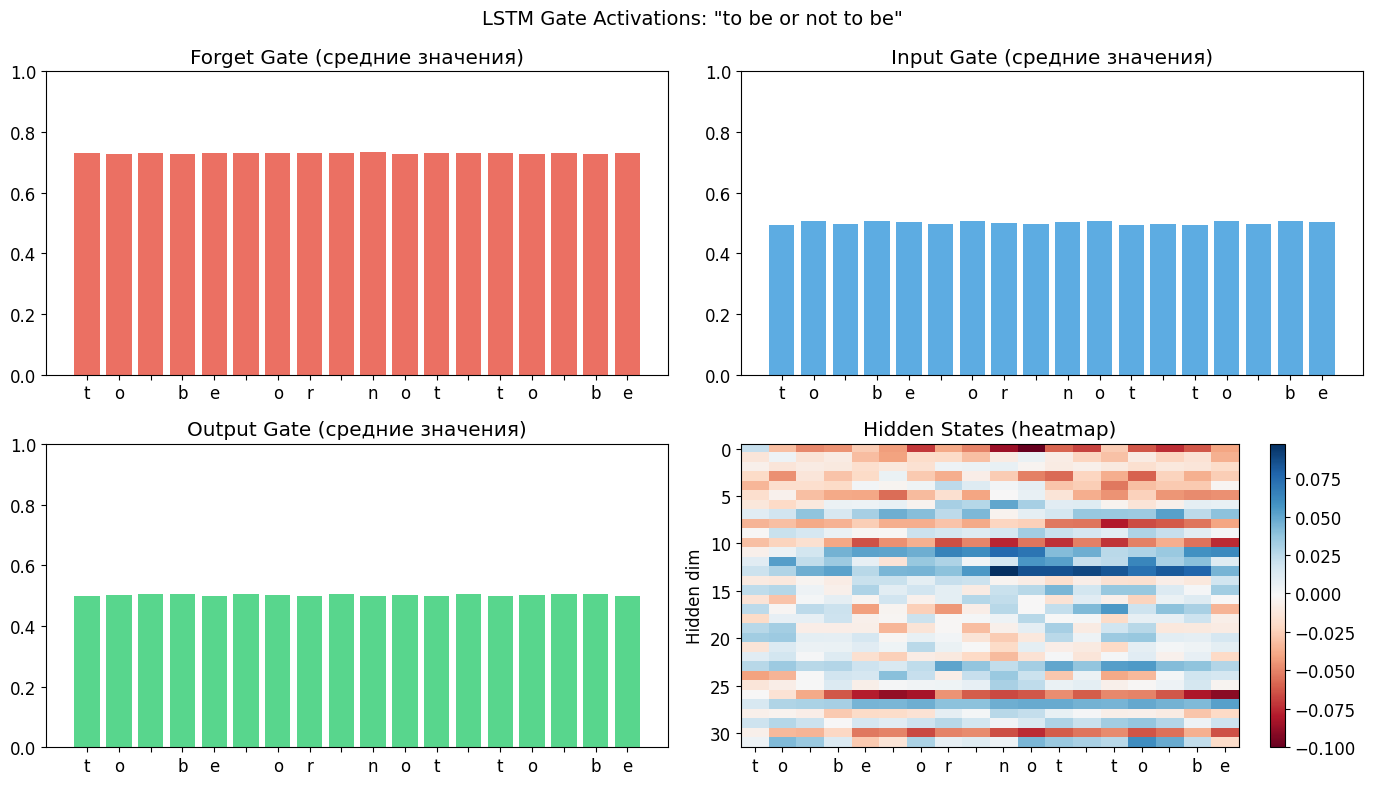

In [42]:
# Используем нашу LSTM с нуля для визуализации gate-активаций
my_lstm_vis = LSTMFromScratch(input_size=64, hidden_size=32)
embed_vis = nn.Embedding(vocab_size, 64)

sample_text = 'to be or not to be'
sample_idx = [char2idx.get(c, 0) for c in sample_text]
x_vis = embed_vis(torch.tensor(sample_idx).unsqueeze(0))  # (1, T, 64)

with torch.no_grad():
    out, h, c, gate_history = my_lstm_vis(x_vis)

# Извлечём средние значения gate-ов
f_vals = [g['f'].mean().item() for g in gate_history]
i_vals = [g['i'].mean().item() for g in gate_history]
o_vals = [g['o'].mean().item() for g in gate_history]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

chars_list = list(sample_text)
x_pos = range(len(chars_list))

axes[0, 0].bar(x_pos, f_vals, color='#e74c3c', alpha=0.8)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(chars_list)
axes[0, 0].set_title('Forget Gate (средние значения)')
axes[0, 0].set_ylim(0, 1)

axes[0, 1].bar(x_pos, i_vals, color='#3498db', alpha=0.8)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(chars_list)
axes[0, 1].set_title('Input Gate (средние значения)')
axes[0, 1].set_ylim(0, 1)

axes[1, 0].bar(x_pos, o_vals, color='#2ecc71', alpha=0.8)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(chars_list)
axes[1, 0].set_title('Output Gate (средние значения)')
axes[1, 0].set_ylim(0, 1)

# Hidden states heatmap
hidden_states = out[0].detach().numpy()  # (T, 32)
im = axes[1, 1].imshow(hidden_states.T, cmap='RdBu', aspect='auto')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(chars_list)
axes[1, 1].set_ylabel('Hidden dim')
axes[1, 1].set_title('Hidden States (heatmap)')
plt.colorbar(im, ax=axes[1, 1])

plt.suptitle('LSTM Gate Activations: "to be or not to be"', fontsize=14)
plt.tight_layout()
plt.savefig('lstm_gates.png', dpi=150, bbox_inches='tight')
plt.show()